In [27]:
import numpy as np
import h5py
import os
import pandas as pd
from tqdm import tqdm
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)

In [28]:
path_to_data_test = '/home/paul/Desktop/data_ped_unc/echonet_ped_preprocessed/TEST/'
path_to_data_inf  = '/home/paul/Desktop/data_ped_unc/predictions/vids/'
path_to_csv       = '/home/paul/Desktop/data_ped_unc/echonet_ped_preprocessed/FileList.csv'

model_name = 'VIDS'

# VIDS stores softmax samples directly (sample_softmax_vids was called during inference)
is_softmax = False

In [29]:
def ncc(a, v, zero_norm=True):
    """Normalized cross-correlation between two arrays."""
    a = a.flatten()
    v = v.flatten()
    eps = 1e-15
    if zero_norm:
        a = (a - np.mean(a)) / (np.std(a) * len(a) + eps)
        v = (v - np.mean(v)) / (np.std(v) + eps)
    else:
        a = (a) / (np.std(a) * len(a) + eps)
        v = (v) / (np.std(v) + eps)
    return np.correlate(a, v)

In [30]:
def to_mean_probs(logits_arr, is_softmax=False):
    """
    logits_arr : (n_samples, n_classes, H, W)
    Returns mean predictive distribution: (n_classes, H, W)
    """
    if not is_softmax:
        # numerically stable softmax over class axis
        shifted = logits_arr - logits_arr.max(axis=1, keepdims=True)
        exp = np.exp(shifted)
        probs = exp / exp.sum(axis=1, keepdims=True)
    else:
        probs = logits_arr
    return probs.mean(axis=0)  # (n_classes, H, W)


def entropy_map(mean_probs):
    """
    Predictive entropy at each pixel.
    mean_probs : (n_classes, H, W)  ->  (H, W)
    """
    eps = 1e-15
    return -(mean_probs * np.log(mean_probs + eps)).sum(axis=0)


def ce_error_map(mean_probs, gt_mask):
    """
    Cross-entropy error at each pixel (how much the mean prediction
    disagrees with the ground truth label).
    mean_probs : (n_classes, H, W)
    gt_mask    : (H, W)  integer class labels
    Returns    : (H, W)
    """
    eps = 1e-15
    H, W = gt_mask.shape
    h_idx = np.arange(H)[:, None]
    w_idx = np.arange(W)[None, :]
    p_gt = mean_probs[gt_mask, h_idx, w_idx]   # probability assigned to the correct class
    return -np.log(p_gt + eps)

In [ ]:
df_csv = pd.read_csv(path_to_csv)

rows = []
file_names = sorted(os.listdir(path_to_data_inf))
print(f'Evaluating {len(file_names)} files...')

for file in tqdm(file_names):
    inf_path = os.path.join(path_to_data_inf, file)
    gt_path  = os.path.join(path_to_data_test, file)

    if not os.path.exists(gt_path):
        continue

    # Look up age from CSV (filename in CSV is .avi, on disk it is .h5)
    csv_row = df_csv[df_csv['FileName'] == file[:-3] + '.avi']
    if len(csv_row) == 0:
        continue
    age       = int(csv_row['Age'].values[0])
    age_group = 'infant' if age == 0 else 'non-infant'

    with h5py.File(inf_path, 'r') as inf_f, h5py.File(gt_path, 'r') as gt_f:
        for phase in ['ed', 'es']:
            if phase not in inf_f or phase not in gt_f:
                continue

            logits_arr = inf_f[phase]['logits'][()]          # (n_samples, n_classes, H, W)
            gt_mask    = gt_f[phase]['mask'][()].astype(int) # (H, W)

            mean_probs = to_mean_probs(logits_arr, is_softmax=is_softmax)  # (n_classes, H, W)

            ent = entropy_map(mean_probs)
            err = ce_error_map(mean_probs, gt_mask)

            ent_sum = ent.sum()

            ncc_val      = float(ncc(ent, err)[0])
            spearman_val = float(stats.spearmanr(ent.flatten(), err.flatten()).statistic)

            rows.append({
                'file':      file,
                'phase':     phase,
                'age':       age,
                'age_group': age_group,
                'ncc':       ncc_val,
                'spearman':  spearman_val,
                'entropy':  ent_sum,
            })

df = pd.DataFrame(rows)
n_inf = (df['age_group'] == 'infant').sum()
n_non = (df['age_group'] == 'non-infant').sum()
print(f'Done. {len(df)} image/phase pairs evaluated.')
print(f'  Infants (age=0): {n_inf} pairs')
print(f'  Non-infants:     {n_non} pairs')

Evaluating 314 files...


100%|██████████| 314/314 [00:02<00:00, 149.12it/s]

Done. 628 image/phase pairs evaluated.
  Infants (age=0): 24 pairs
  Non-infants:     604 pairs


In [ ]:
print(f'=== {model_name} — Uncertainty vs Error Correlation ===\n')

groups = [
    ('All',          df),
    ('Infants',      df[df['age_group'] == 'infant']),
    ('Non-infants',  df[df['age_group'] == 'non-infant']),
]

for label, sub in groups:
    print(f'{label} (N={len(sub)}):')
    print(f'  NCC:      {sub["ncc"].mean():.4f} +/- {sub["ncc"].std():.4f}')
    print(f'  Spearman: {sub["spearman"].mean():.4f} +/- {sub["spearman"].std():.4f}')
    print(f'  Entropy: {sub["entropy"].mean():.4f} +/- {sub["entropy"].std():.4f}')
    print()

=== VIDS — Uncertainty vs Error Correlation ===

All (N=628):
  NCC:      0.4993 +/- 0.1512
  Spearman: 0.9989 +/- 0.0065

Infants (N=24):
  NCC:      0.5363 +/- 0.1424
  Spearman: 0.9908 +/- 0.0288

Non-infants (N=604):
  NCC:      0.4978 +/- 0.1515
  Spearman: 0.9992 +/- 0.0031



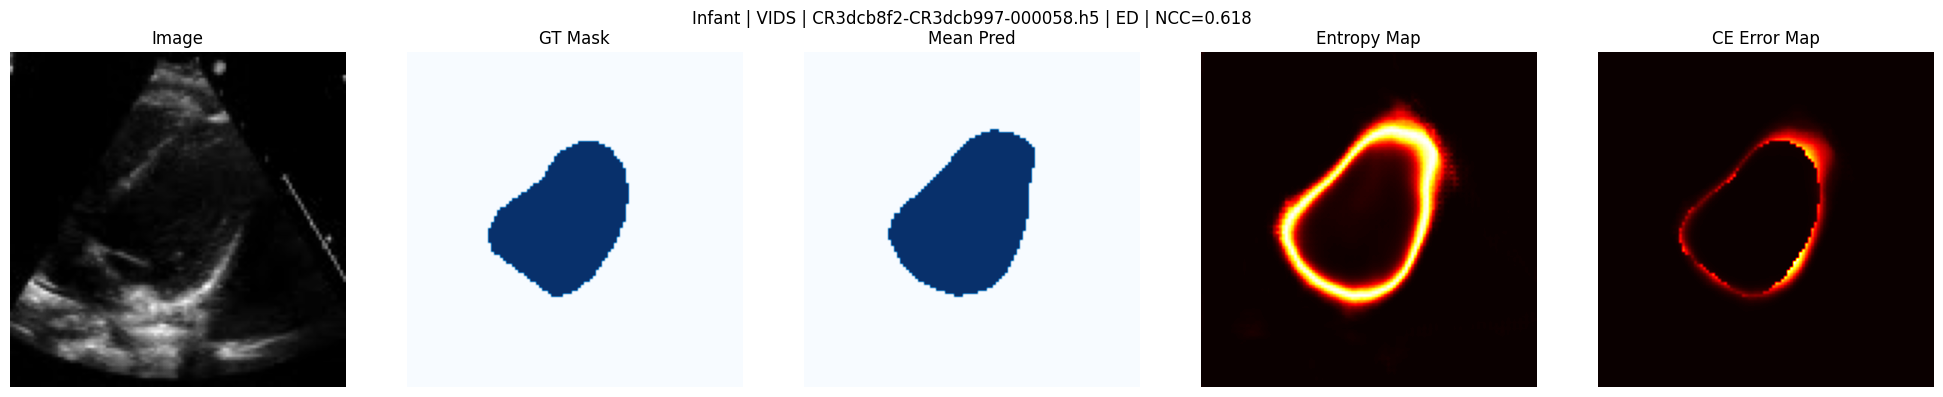

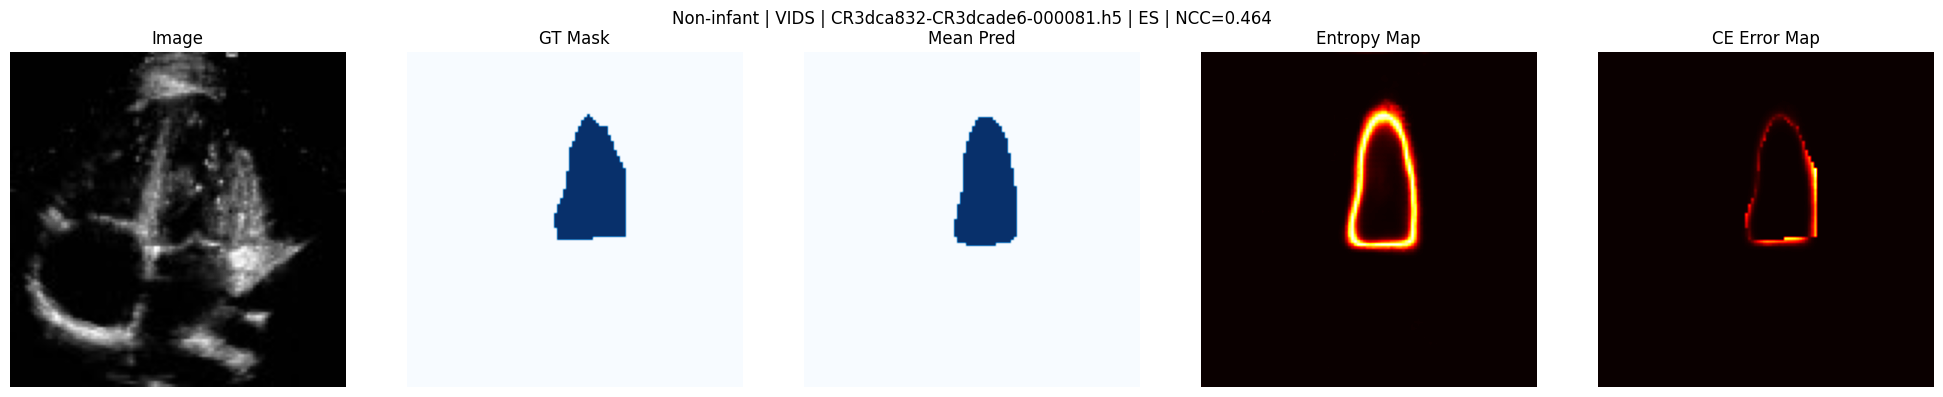

In [33]:
def plot_example(sample, title_prefix):
    with h5py.File(os.path.join(path_to_data_inf,  sample['file']), 'r') as inf_f, \
         h5py.File(os.path.join(path_to_data_test, sample['file']), 'r') as gt_f:
        logits_arr = inf_f[sample['phase']]['logits'][()]
        gt_mask    = gt_f[sample['phase']]['mask'][()].astype(int)
        img        = gt_f[sample['phase']]['image'][()]

    mean_probs = to_mean_probs(logits_arr, is_softmax=is_softmax)
    ent  = entropy_map(mean_probs)
    err  = ce_error_map(mean_probs, gt_mask)
    pred = np.argmax(mean_probs, axis=0)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    axes[0].imshow(img,     cmap='gray');  axes[0].set_title('Image');        axes[0].axis('off')
    axes[1].imshow(gt_mask, cmap='Blues'); axes[1].set_title('GT Mask');      axes[1].axis('off')
    axes[2].imshow(pred,    cmap='Blues'); axes[2].set_title('Mean Pred');    axes[2].axis('off')
    axes[3].imshow(ent,     cmap='hot');   axes[3].set_title('Entropy Map');  axes[3].axis('off')
    axes[4].imshow(err,     cmap='hot');   axes[4].set_title('CE Error Map'); axes[4].axis('off')
    fig.suptitle(f'{title_prefix} | {model_name} | {sample["file"]} | {sample["phase"].upper()} '
                 f'| NCC={sample["ncc"]:.3f}')
    plt.tight_layout()
    plt.show()


np.random.seed(0)
infant_sample     = df[df['age_group'] == 'infant'].sample(10).iloc[2]
non_infant_sample = df[df['age_group'] == 'non-infant'].sample(1).iloc[0]

plot_example(infant_sample,     'Infant')
plot_example(non_infant_sample, 'Non-infant')